# Project: Colon Cancer Classification (MobileNetV2)
**Author:** Ahmed Ayman Ahmed Alhofy  
**Dataset:** [Colon Cancer Datasets (Kaggle)](https://www.kaggle.com/datasets/apngupta/colon-cancer-datasets)

## ⚠️ Critical Diagnostic: Data Leakage & Split Error

The model is failing to learn because the **Test Set is contaminated/unlabeled**, leading to invalid evaluation metrics and potential data leakage during preprocessing.

### Diagnostics Summary
| Metric | Count | Note |
| :--- | :--- | :--- |
| **Total Images** | 7,560 | |
| **Labeled (CSV)** | 2,190 | Only ~29% of data has labels |
| **Unlabeled** | 5,370 | **⚠️ Major Issue** |
| **Training Set** | 1,752 | 4 Classes (Balanced?) |
| **Validation Set** | 438 | 4 Classes |
| **Test Set** | **5,041** | **❌ 1 Class Only** |

### Why the Model Fails
1.  **Invalid Test Set:** The test set contains **5,041 images belonging to only 1 class**. This suggests the "unlabeled" folder images were dumped into the test split without proper labeling or filtering. You cannot evaluate a 4-class classifier on a single-class test set.
2.  **Performance Ceiling:** With only 2,190 labeled images for 4 classes (~550 per class), the dataset is small for training MobileNetV2 from scratch, leading to overfitting (Train Acc: ~49% vs Val Acc: ~28%).
3.  **Learning Rate Collapse:** The `ReduceLROnPlateau` triggered early (Epoch 7 & 9) because validation loss stalled, indicating the model cannot generalize beyond the limited training data.

### Recommended Fixes
- [ ] **Exclude Unlabeled Data:** Remove the 5,370 unlabeled images from the pipeline entirely until they are annotated.
- [ ] **Correct Split:** Perform a stratified train/val/test split (e.g., 70/15/15) **only** on the 2,190 labeled images.
- [ ] **Data Augmentation:** Aggressively augment the small training set (rotation, flip, zoom) to improve generalization.
- [ ] **Transfer Learning:** Freeze more layers of MobileNetV2 initially, as the dataset is too small for fine-tuning all layers immediately.

# Deep Learning Setup for Image Classification

Importing essential libraries for building and evaluating CNN-based image classifiers:
- **TensorFlow/Keras** with pre-trained backbones (`ResNet50`, `MobileNetV2`)
- **Data loading** via `image_dataset_from_directory`
- **Training utilities**: callbacks for early stopping, learning rate scheduling, and progress tracking
- **Evaluation tools**: classification report and confusion matrix from scikit-learn
- Configured for reproducibility and clean output (warnings suppressed)

In [1]:
# Core libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tqdm.keras import TqdmCallback

# Scikit-learn (for evaluation metrics)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Optional (for reproducibility)
import random

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Colon Cancer Histopathology Dataset Setup

Downloaded the **Colon Cancer Histopathology Image Dataset** from Kaggle and configured data pipelines for training, validation, and test sets:
- **Robust file-label alignment**: Automatically appends correct image extensions and verifies CSV-to-disk consistency.
- **Diagnostics**: Reports mismatches between labeled IDs and actual files to ensure data integrity.
- **Preprocessing**: Uses `ImageDataGenerator` with 1/255 rescaling and an 80/20 train/validation split.
- **Input specs**: Images resized to 224×224 (compatible with ResNet/MobileNet), batch size = 16.

Ready for transfer learning or custom CNN training on 4-class colon tissue classification.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("apngupta/colon-cancer-datasets")

print("Path to dataset files:", path)

100%|██████████| 224M/224M [00:03<00:00, 60.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/apngupta/colon-cancer-datasets/versions/2


In [3]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# 1. Path Configuration
base_dir = "/root/.cache/kagglehub/datasets/apngupta/colon-cancer-datasets/versions/2"
train_dir = os.path.join(base_dir, "train", "train")
test_dir = os.path.join(base_dir, "test", "test")
train_csv_path = os.path.join(base_dir, "train.csv")

# 2. Parameters
img_height, img_width = 224, 224
batch_size = 16

# 3. Load and Prepare Label Data
train_df = pd.read_csv(train_csv_path)

# According to dataset info: 'Id' is the filename/ID, 'Type' is the label
x_col = "Id"
y_col = "Type"

# Ensure IDs are strings for the generator
train_df[x_col] = train_df[x_col].astype(str)

# Logic to handle missing file extensions in the CSV
if os.path.exists(train_dir) and len(os.listdir(train_dir)) > 0:
    actual_files = os.listdir(train_dir)
    sample_file = actual_files[0]
    _, extension = os.path.splitext(sample_file)

    # Apply extension if missing
    def ensure_extension(fn):
        if not fn.lower().endswith(('.jpg', '.png', '.jpeg')):
            return fn + extension
        return fn

    train_df[x_col] = train_df[x_col].apply(ensure_extension)

    # DATASET HEALTH CHECK
    files_on_disk = set(actual_files)
    ids_in_csv = set(train_df[x_col])
    matches = ids_in_csv.intersection(files_on_disk)

    print("-" * 30)
    print(f"DIAGNOSTICS:")
    print(f"Total images found in folder: {len(files_on_disk)}")
    print(f"Total IDs listed in CSV:      {len(ids_in_csv)}")
    print(f"Matching files found:         {len(matches)}")
    print(f"Missing from folder:          {len(ids_in_csv - files_on_disk)}")
    print(f"Unlabeled in folder:          {len(files_on_disk - ids_in_csv)}")
    print("-" * 30)

# 4. Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

# 5. Training Dataset (80% of matched CSV entries)
train_ds = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_dir,
    x_col=x_col,
    y_col=y_col,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

# 6. Validation Dataset (20% of matched CSV entries)
val_ds = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_dir,
    x_col=x_col,
    y_col=y_col,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=True
)

# 7. Test Dataset (Unlabeled)
test_ds = test_datagen.flow_from_directory(
    directory=os.path.join(base_dir, "test"),
    classes=['test'],
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode=None,
    shuffle=False
)

# 8. Final Summary
print("-" * 30)
print(f"Final Training samples:   {train_ds.samples}")
print(f"Final Validation samples: {val_ds.samples}")
print(f"Final Test samples:       {test_ds.samples}")
if train_ds.samples > 0:
    print(f"Classes detected:         {list(train_ds.class_indices.keys())}")

------------------------------
DIAGNOSTICS:
Total images found in folder: 7560
Total IDs listed in CSV:      2190
Matching files found:         2190
Missing from folder:          0
Unlabeled in folder:          5370
------------------------------
Found 1752 validated image filenames belonging to 4 classes.
Found 438 validated image filenames belonging to 4 classes.
Found 5041 images belonging to 1 classes.
------------------------------
Final Training samples:   1752
Final Validation samples: 438
Final Test samples:       5041
Classes detected:         ['Cancer', 'Connective', 'Immune', 'Normal']


# Visualize Sample Training Images

Displays a 3×4 grid of sample histopathology images from the training set, each labeled with its corresponding class (e.g., "benign", "malignant"). This visual check confirms:
- Correct image loading and preprocessing (RGB, normalized)
- Accurate label assignment via `class_indices`
- Data diversity across tissue types

Ensures the pipeline is ready for model training.


Plotting 12 smaller sample images...


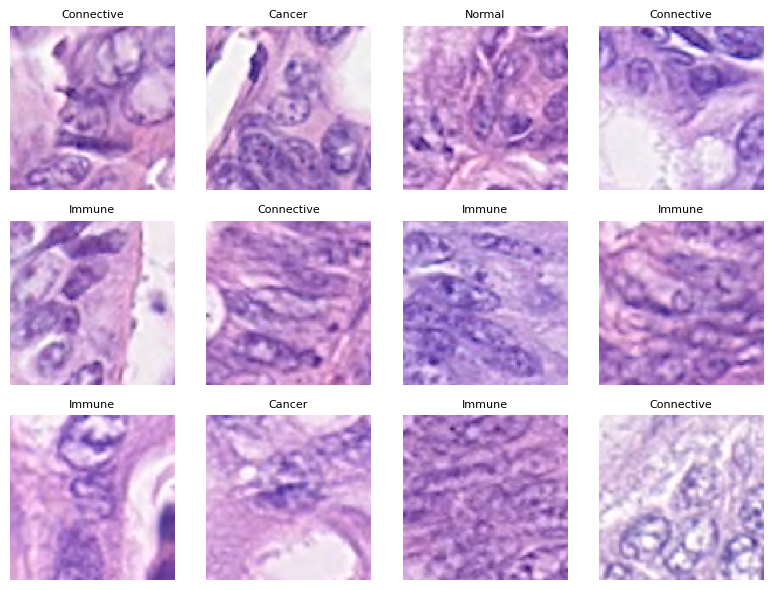

In [4]:
# 9. Preview Images (Visualization Section)
if train_ds.samples > 0:
    # Always extract class names directly from the generator used for plotting
    label_map = {v: k for k, v in train_ds.class_indices.items()}

    print("\nPlotting 12 smaller sample images...")
    # Adjusted figsize for a 3x4 grid
    plt.figure(figsize=(8, 6))

    # Fetch one batch
    images, labels = next(train_ds)

    # Display 12 images in a 3x4 grid
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        # Display image
        plt.imshow(images[i])

        # Get the class name using the reverse mapping
        label_idx = np.argmax(labels[i])
        plt.title(label_map[label_idx], fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("\nNo samples found to plot.")

# Train MobileNetV2 for Colon Cancer Classification

Built a transfer learning model using **MobileNetV2** (pretrained on ImageNet) with:
- Frozen base layers for feature extraction
- Global average pooling + dropout (0.3) + softmax classifier head

Trained on histopathology images with:
- **Optimizer**: Adam (lr=0.001)
- **Loss**: Categorical crossentropy (matches one-hot labels from `flow_from_dataframe`)
- **Callbacks**: Early stopping (patience=5) and learning rate reduction (factor=0.2, patience=2)

Model adapts efficiently to the 4-class colon tissue classification task while leveraging learned visual features.

In [5]:
# 10. Model Building (MobileNetV2)
def build_mobilenet(num_classes):
    base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(img_height, img_width, 3))
    base_model.trainable = False  # Freeze base model

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

# Set dynamic number of classes from our data
num_classes = len(train_ds.class_indices)

# Define Callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

# Compile Model
mobilenet_model = build_mobilenet(num_classes)
mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001), # Safer default
    loss="categorical_crossentropy", # Changed from sparse as we use one-hot labels
    metrics=["accuracy"]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# 11. Training
print(f"\nTraining MobileNetV2 on {num_classes} classes...")
history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)


Training MobileNetV2 on 4 classes...
Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 56s 318ms/step - accuracy: 0.3368 - loss: 1.5615 - val_accuracy: 0.1895 - val_loss: 1.5593 - learning_rate: 0.0010
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.3841 - loss: 1.3998 - val_accuracy: 0.2763 - val_loss: 1.4409 - learning_rate: 0.0010
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.4024 - loss: 1.3302 - val_accuracy: 0.2671 - val_loss: 1.3830 - learning_rate: 0.0010
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.4161 - loss: 1.3080 - val_accuracy: 0.2763 - val_loss: 1.4158 - learning_rate: 0.0010
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.4338 - loss: 1.2512 - val_accuracy: 0.4224 - val_loss: 1.1766 - learning_rate: 0.0010
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.4543 - loss: 1.2137 - val_accuracy: 0.3584 - val_loss: 1.2571 - learning_rate: 0.0010
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s